In [92]:
import pandas as pd

df = pd.read_csv("merged_sequences_flat.csv")

# Keep only rows where finalLabel != -1
df_clean = df[df['finalLabel'] != -1]

# Save back to CSV
df_clean.to_csv("merged_sequences_flat_clean.csv", index=False)

print("Before:", len(df))
print("After:", len(df_clean))
print("Deleted:", len(df) - len(df_clean))


Before: 13992
After: 10140
Deleted: 3852


In [1]:
import numpy as np
import os
import shutil
from qonnx.core.modelwrapper import ModelWrapper
from finn.core.onnx_exec import execute_onnx
# os.chdir('/mnt/c/Users/An/finn/notebooks/sin_pulse')
# =========================================================
# CONFIGURATION
# =========================================================
# Input Data (From your code)
input_string = "0.028839 0.028992 0.133209 0.466003 1.163788 1.796722 2.02179 2.192993 1.581421 0.186615 -1.128082 -2.048035 -2.098236 -2.062378 -1.535034 -0.7724 -0.285645 -0.050354"

OUTPUT_SCALE = 0.08270524442195892

raw_list = [float(x) for x in input_string.split()]

# Pad to 20
if len(raw_list) < 20: 
    raw_list += [0.0] * (20 - len(raw_list))


print(f"Input Data (First 5): {raw_list[:5]}")

print("\n[1/2] Running Golden Model...")
model_golden = ModelWrapper("finn_ready_model.onnx")
inp_name_gold = model_golden.graph.input[0].name
out_name_gold = model_golden.graph.output[0].name

# Reshape
inp_golden = np.array(raw_list, dtype=np.float32).reshape(1, 1, 1, 20)

ret_golden = execute_onnx(model_golden, {inp_name_gold: inp_golden})
res_golden_logit = ret_golden[out_name_gold].flatten()[0]

# Sigmoid
prob_golden = 1.0 / (1.0 + np.exp(-res_golden_logit))
class_golden = 1 if prob_golden > 0.5 else 0

print(f"   Golden Logit: {res_golden_logit:.4f}")
print(f"   Golden Prob:  {prob_golden:.4f}")

print("\n[2/2] Running Hardware Simulation...")
model_hw = ModelWrapper("./output/intermediate_models/step_measure_rtlsim_performance.onnx")


inp_scale = 0.0390625 

inp_hw_int = []
for val in raw_list:
    # Chia cho scale
    scaled = val / inp_scale

    q_val = np.clip(np.round(scaled), -128, 127)
    inp_hw_int.append(q_val)

print(f"Corrected HW Input (First 5): {inp_hw_int[:5]}")

# Shape Setup
inp_name_hw = model_hw.graph.input[0].name
inp_shape_hw = model_hw.get_tensor_shape(inp_name_hw)

inp_hw = np.array(inp_hw_int, dtype=np.float32).reshape(inp_shape_hw)

model_hw.set_metadata_prop("exec_mode", "rtlsim")

# Execute
ret_hw = execute_onnx(model_hw, {inp_name_hw: inp_hw})
out_name_hw = model_hw.graph.output[0].name
res_hw_int = ret_hw[out_name_hw].flatten()[0] # This is INT32

print("\n" + "="*40)
print("FINAL COMPARISON")
print("="*40)

# 1. Recover the Float value from Hardware
res_hw_recovered = res_hw_int * OUTPUT_SCALE

print(f"{'Metric':<20} | {'Golden (Float)':<15} | {'Hardware (Int)':<15} | {'HW (Scaled)':<15}")
print("-" * 75)
print(f"{'Raw Output':<20} | {res_golden_logit:<15.4f} | {int(res_hw_int):<15} | {res_hw_recovered:<15.4f}")


hw_class = 1 if res_hw_recovered > 0 else 0

print("-" * 75)
print(f"Predicted Class:     | {class_golden}               | {hw_class}")
print("-" * 75)

if class_golden == hw_class:
    print("✅ MATCH: Both models predict the same class.")
    if abs(res_golden_logit - res_hw_recovered) > 0.5:
         print("   (Note: Raw values differ slightly due to quantization errors, which is normal)")
else:
    print("❌ MISMATCH: The predictions differ.")
    print("   Check: 1. Did you verify the 'np.flip' is required?")
    print("          2. Is the training range really -5.0 to 5.0?")

Input Data (First 5): [0.028839, 0.028992, 0.133209, 0.466003, 1.163788]

[1/2] Running Golden Model...
   Golden Logit: 6.6991
   Golden Prob:  0.9988

[2/2] Running Hardware Simulation...
Corrected HW Input (First 5): [1.0, 1.0, 3.0, 12.0, 30.0]


%Warning-MODDUP: /tmp/finn_dev_cutesquare/vivado_stitch_proj_csv3a__b/finn_design_wrapper.v:4593:8: Duplicate declaration of module: 'dwc_axi'
 4593 | module dwc_axi #(
      |        ^~~~~~~
                 /tmp/finn_dev_cutesquare/vivado_stitch_proj_csv3a__b/finn_design_wrapper.v:289:8: ... Location of original declaration
  289 | module dwc_axi #(
      |        ^~~~~~~
                 ... For warning description see https://verilator.org/warn/MODDUP?v=4.224
                 ... Use "/* verilator lint_off MODDUP */" and lint_on around source to disable this message.
%Warning-MODDUP: /tmp/finn_dev_cutesquare/vivado_stitch_proj_csv3a__b/finn_design_wrapper.v:10617:8: Duplicate declaration of module: 'dwc_axi'
10617 | module dwc_axi #(
      |        ^~~~~~~
                 /tmp/finn_dev_cutesquare/vivado_stitch_proj_csv3a__b/finn_design_wrapper.v:289:8: ... Location of original declaration
  289 | module dwc_axi #(
      |        ^~~~~~~
%Warning-MODDUP: /tmp/finn_dev_cutesquare/vi

make: Entering directory '/tmp/finn_dev_cutesquare/pyverilator_ipstitched_0wv25za0'
ccache g++  -I.  -MMD -I/usr/local/share/verilator/include -I/usr/local/share/verilator/include/vltstd -DVM_COVERAGE=0 -DVM_SC=0 -DVM_TRACE=1 -DVM_TRACE_FST=0 -DVM_TRACE_VCD=1 -faligned-new -fcf-protection=none -Wno-bool-operation -Wno-sign-compare -Wno-uninitialized -Wno-unused-but-set-variable -Wno-unused-parameter -Wno-unused-variable -Wno-shadow     -fPIC --std=c++11  -std=gnu++17 -Os -c -o pyverilator_wrapper.o /tmp/finn_dev_cutesquare/pyverilator_ipstitched_0wv25za0/pyverilator_wrapper.cpp
ccache g++  -I.  -MMD -I/usr/local/share/verilator/include -I/usr/local/share/verilator/include/vltstd -DVM_COVERAGE=0 -DVM_SC=0 -DVM_TRACE=1 -DVM_TRACE_FST=0 -DVM_TRACE_VCD=1 -faligned-new -fcf-protection=none -Wno-bool-operation -Wno-sign-compare -Wno-uninitialized -Wno-unused-but-set-variable -Wno-unused-parameter -Wno-unused-variable -Wno-shadow     -fPIC --std=c++11  -std=gnu++17 -Os -c -o verilated.o /usr/

In [8]:
import numpy as np
import os
import shutil
from qonnx.core.modelwrapper import ModelWrapper
from finn.core.onnx_exec import execute_onnx
# =========================================================
# CONFIGURATION
# =========================================================
# Input Data (From your code)
input_string = "0.028839 0.028992 0.133209 0.466003 1.163788 1.796722 2.02179 2.192993 1.581421 0.186615 -1.128082 -2.048035 -2.098236 -2.062378 -1.535034 -0.7724 -0.285645 -0.050354"

OUTPUT_SCALE = 0.08270524442195892

raw_list = [float(x) for x in input_string.split()]

if len(raw_list) < 20: 
    raw_list += [0.0] * (20 - len(raw_list))


print(f"Input Data (First 5): {raw_list[:5]}")

print("\n[1/2] Running Golden Model...")
model_golden = ModelWrapper("finn_ready_model.onnx")
inp_name_gold = model_golden.graph.input[0].name
out_name_gold = model_golden.graph.output[0].name

# Reshape
inp_golden = np.array(raw_list, dtype=np.float32).reshape(1, 1, 1, 20)

ret_golden = execute_onnx(model_golden, {inp_name_gold: inp_golden})
res_golden_logit = ret_golden[out_name_gold].flatten()[0]

# Sigmoid
prob_golden = 1.0 / (1.0 + np.exp(-res_golden_logit))
class_golden = 1 if prob_golden > 0.5 else 0

print(f"   Golden Logit: {res_golden_logit:.4f}")
print(f"   Golden Prob:  {prob_golden:.4f}")

print("\n[2/2] Running Hardware Simulation...")
model_debug  = ModelWrapper("./output/intermediate_models/step_create_stitched_ip.onnx")

    
inp_scale = 0.0390625 

inp_hw_int = []
for val in raw_list:
    # Chia cho scale
    scaled = val / inp_scale

    q_val = np.clip(np.round(scaled), -128, 127)
    inp_hw_int.append(q_val)

print(f"Corrected HW Input (First 5): {inp_hw_int[:5]}")

inp_debug = np.array(inp_hw_int, dtype=np.float32).reshape(model_debug.get_tensor_shape(model_debug.graph.input[0].name))

input_dict = {model_debug.graph.input[0].name: inp_debug}
context = execute_onnx(model_debug, input_dict, return_full_exec_context=True)

# 4. Print EVERY intermediate tensor
print("\n" + "="*50)
print("DEBUG: LAYER-BY-LAYER OUTPUT")
print("="*50)

for tensor_name in context:
    data = context[tensor_name]
    shape = data.shape
    # Filter out empty or uninteresting tensors if needed
    print(f"Tensor: {tensor_name}")
    print(f"Shape:  {shape}")
    print(f"Values: {data.flatten()}") # Print first 10 values
    print("-" * 30)

# Check the final output from this context
final_out_name = model_debug.graph.output[0].name
print(f"Final Logic Output: {context[final_out_name]}")

Input Data (First 5): [0.028839, 0.028992, 0.133209, 0.466003, 1.163788]

[1/2] Running Golden Model...
   Golden Logit: 6.6991
   Golden Prob:  0.9988

[2/2] Running Hardware Simulation...
Corrected HW Input (First 5): [1.0, 1.0, 3.0, 12.0, 30.0]


%Warning-MODDUP: /tmp/finn_dev_cutesquare/vivado_stitch_proj_cy8lz0z7/finn_design_wrapper.v:5318:8: Duplicate declaration of module: 'dwc_axi'
 5318 | module dwc_axi #(
      |        ^~~~~~~
                 /tmp/finn_dev_cutesquare/vivado_stitch_proj_cy8lz0z7/finn_design_wrapper.v:3239:8: ... Location of original declaration
 3239 | module dwc_axi #(
      |        ^~~~~~~
                 ... For warning description see https://verilator.org/warn/MODDUP?v=4.224
                 ... Use "/* verilator lint_off MODDUP */" and lint_on around source to disable this message.
%Warning-MODDUP: /tmp/finn_dev_cutesquare/vivado_stitch_proj_cy8lz0z7/finn_design_wrapper.v:11630:8: Duplicate declaration of module: 'dwc'
11630 | module dwc #(
      |        ^~~
                 /tmp/finn_dev_cutesquare/vivado_stitch_proj_cy8lz0z7/finn_design_wrapper.v:333:8: ... Location of original declaration
  333 | module dwc #(
      |        ^~~
%Warning-MODDUP: /tmp/finn_dev_cutesquare/vivado_stitch_proj_cy

make: Entering directory '/tmp/finn_dev_cutesquare/pyverilator_ipstitched_1ggdbb1o'
ccache g++  -I.  -MMD -I/usr/local/share/verilator/include -I/usr/local/share/verilator/include/vltstd -DVM_COVERAGE=0 -DVM_SC=0 -DVM_TRACE=1 -DVM_TRACE_FST=0 -DVM_TRACE_VCD=1 -faligned-new -fcf-protection=none -Wno-bool-operation -Wno-sign-compare -Wno-uninitialized -Wno-unused-but-set-variable -Wno-unused-parameter -Wno-unused-variable -Wno-shadow     -fPIC --std=c++11  -std=gnu++17 -Os -c -o pyverilator_wrapper.o /tmp/finn_dev_cutesquare/pyverilator_ipstitched_1ggdbb1o/pyverilator_wrapper.cpp
ccache g++  -I.  -MMD -I/usr/local/share/verilator/include -I/usr/local/share/verilator/include/vltstd -DVM_COVERAGE=0 -DVM_SC=0 -DVM_TRACE=1 -DVM_TRACE_FST=0 -DVM_TRACE_VCD=1 -faligned-new -fcf-protection=none -Wno-bool-operation -Wno-sign-compare -Wno-uninitialized -Wno-unused-but-set-variable -Wno-unused-parameter -Wno-unused-variable -Wno-shadow     -fPIC --std=c++11  -std=gnu++17 -Os -c -o verilated.o /usr/

In [8]:
import numpy as np
from qonnx.core.modelwrapper import ModelWrapper
from finn.core.onnx_exec import execute_onnx

print("\n[1/2] Running Golden Model with Layer Debugging...")
model_golden = ModelWrapper("finn_ready_model.onnx")
inp_name_gold = model_golden.graph.input[0].name
out_name_gold = model_golden.graph.output[0].name

# Reshape Input
inp_golden = np.array(raw_list, dtype=np.float32).reshape(1, 1, 1, 20)
input_dict = {inp_name_gold: inp_golden}

context_golden = execute_onnx(model_golden, input_dict, return_full_exec_context=True)

print("\n" + "="*50)
print("DEBUG: GOLDEN MODEL LAYERS")
print("="*50)

for tensor_name, data in context_golden.items():
    # Skip the input tensor if you want, or keep it
    shape = data.shape
    flat_data = data.flatten()
    
    print(f"Tensor: {tensor_name}")
    print(f"Shape:  {shape}")
    
    # Print first 10 values to keep log clean, or all if small
    if len(flat_data) > 20:
        print(f"Values (First 20): {flat_data[:20]} ...")
    else:
        print(f"Values: {flat_data}")
    print("-" * 30)



[1/2] Running Golden Model with Layer Debugging...

DEBUG: GOLDEN MODEL LAYERS
Tensor: global_in
Shape:  (1, 1, 1, 20)
Values: [ 0.028839  0.028992  0.133209 -0.7724   -0.285645 -0.050354 -0.7724
 -0.285645 -0.050354  0.        0.        0.        0.        0.
  0.        0.        0.        0.        0.        0.      ]
------------------------------
Tensor: global_out
Shape:  (1, 1)
Values: [-0.8270525]
------------------------------
Tensor: Quant_0_out0
Shape:  (1, 1, 1, 20)
Values: [ 0.0390625  0.0390625  0.1171875 -0.78125   -0.2734375 -0.0390625
 -0.78125   -0.2734375 -0.0390625  0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.       ]
------------------------------
Tensor: Quant_1_out0
Shape:  (8, 1, 1, 8)
Values (First 20): [ 0.         -0.0752847  -0.30113882 -0.30113882 -0.45170823 -0.30113882
  0.15056941 -0.45170823 -0.15056941  0.37642354  0.0752847   0.37642354
 -0.15056941 -0.0752847  -0.30113882 -0.0752847   0.0752847

In [4]:
import numpy as np


input_string = "0.028839 0.028992 0.133209 0.466003 1.163788 1.796722 2.02179 2.192993 1.581421 0.186615 -1.128082 -2.048035 -2.098236 -2.062378 -1.535034 -0.7724 -0.285645 -0.050354"
raw_list = [float(x) for x in input_string.split()]
if len(raw_list) < 20: 
    raw_list += [0.0] * (20 - len(raw_list))

inp_scale = 0.0390625 
inp_hw_int = []

print("Generating Hex file for Vivado...")
with open("input_data.mem", "w") as f:
    for val in raw_list:
        scaled = val / inp_scale

        q_val = int(np.clip(np.round(scaled), -128, 127))
        
        # 3. Chuyển sang 2's Complement Hex (8-bit)
        # Python hiểu số âm là -10, nhưng Vivado cần F6
        hex_val = q_val & 0xFF 
        
        f.write(f"{hex_val:02x}\n") # Ghi từng dòng 1 byte (vd: f6)
        print(f"Dec: {q_val:4d} -> Hex: {hex_val:02x}")


Generating Hex file for Vivado...
Dec:    1 -> Hex: 01
Dec:    1 -> Hex: 01
Dec:    3 -> Hex: 03
Dec:   12 -> Hex: 0c
Dec:   30 -> Hex: 1e
Dec:   46 -> Hex: 2e
Dec:   52 -> Hex: 34
Dec:   56 -> Hex: 38
Dec:   40 -> Hex: 28
Dec:    5 -> Hex: 05
Dec:  -29 -> Hex: e3
Dec:  -52 -> Hex: cc
Dec:  -54 -> Hex: ca
Dec:  -53 -> Hex: cb
Dec:  -39 -> Hex: d9
Dec:  -20 -> Hex: ec
Dec:   -7 -> Hex: f9
Dec:   -1 -> Hex: ff
Dec:    0 -> Hex: 00
Dec:    0 -> Hex: 00


[1/3] Đang tạo vector đầu vào với xung sin hẹp...
Vector đã tạo (Tổng 20 điểm): [ 0.00000000e+00 -3.09016994e-01 -5.87785252e-01 -8.09016994e-01
 -9.51056516e-01 -1.00000000e+00 -9.51056516e-01 -8.09016994e-01
 -5.87785252e-01 -3.09016994e-01 -1.22464680e-16  3.09016994e-01
  5.87785252e-01  8.09016994e-01  9.51056516e-01  1.00000000e+00
  9.51056516e-01  8.09016994e-01  5.87785252e-01  3.09016994e-01]
Chiều rộng xung: 20, Điện thế chung (Padding): 2.0V
[2/3] Đang vẽ biểu đồ vector đầu vào...


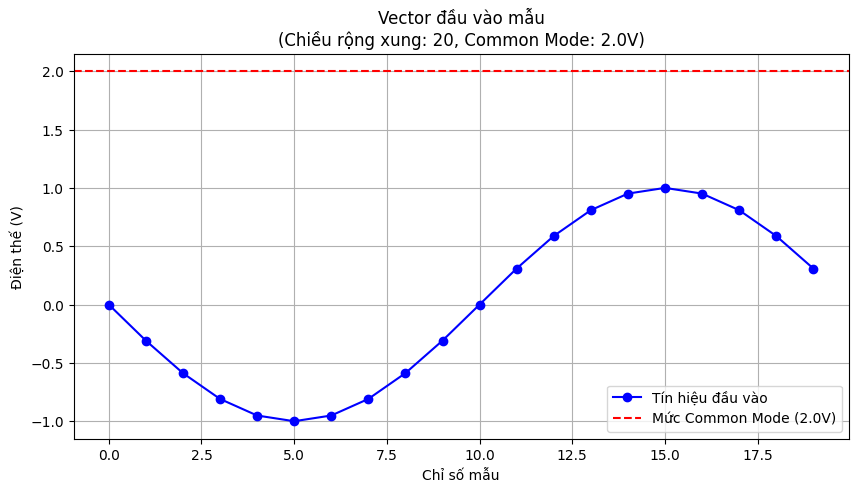


[3/3] Đang chạy mô hình Golden để phân loại...
------------------------------
Kết quả dự đoán của mô hình Golden:
   Logit: -0.4962
   Xác suất (Probability): 0.3784
   Lớp dự đoán (Predicted Class): 0
------------------------------


In [11]:
import numpy as np
import os
from qonnx.core.modelwrapper import ModelWrapper
from finn.core.onnx_exec import execute_onnx
import matplotlib.pyplot as plt

# Thiết lập thư mục làm việc nếu cần thiết
# os.chdir('/mnt/c/Users/An/finn/notebooks/sin_pulse')

# =========================================================
# CONFIGURATION
# =========================================================
# Tổng số điểm trong vector đầu vào (cố định theo yêu cầu mô hình)
NUM_POINTS = 20

SINE_PULSE_WIDTH = 20

COMMON_VOLTAGE = 2.0

GOLDEN_MODEL_PATH = "finn_ready_model.onnx"


print("[1/3] Đang tạo vector đầu vào với xung sin hẹp...")


input_vector = np.full(NUM_POINTS, COMMON_VOLTAGE)

t_pulse = np.linspace(0, -2 * np.pi , SINE_PULSE_WIDTH, endpoint=False)
sine_pulse = np.sin(t_pulse)

start_idx = (NUM_POINTS - SINE_PULSE_WIDTH) // 2
end_idx = start_idx + SINE_PULSE_WIDTH

input_vector[start_idx : end_idx] = sine_pulse

print(f"Vector đã tạo (Tổng {NUM_POINTS} điểm): {input_vector}")
print(f"Chiều rộng xung: {SINE_PULSE_WIDTH}, Điện thế chung (Padding): {COMMON_VOLTAGE}V")

print("[2/3] Đang vẽ biểu đồ vector đầu vào...")
plt.figure(figsize=(10, 5))
plt.plot(input_vector, marker='o', linestyle='-', color='b', label='Tín hiệu đầu vào')
plt.title(f"Vector đầu vào mẫu\n(Chiều rộng xung: {SINE_PULSE_WIDTH}, Common Mode: {COMMON_VOLTAGE}V)")
plt.xlabel("Chỉ số mẫu")
plt.ylabel("Điện thế (V)")
plt.grid(True)

plt.axhline(COMMON_VOLTAGE, color='r', linestyle='--', label=f'Mức Common Mode ({COMMON_VOLTAGE}V)')
plt.legend()
plt.show()

print("\n[3/3] Đang chạy mô hình Golden để phân loại...")

if not os.path.exists(GOLDEN_MODEL_PATH):
    print(f"Lỗi: Không tìm thấy file mô hình '{GOLDEN_MODEL_PATH}'. Vui lòng đảm bảo file tồn tại trong thư mục hiện tại.")
else:
    model_golden = ModelWrapper(GOLDEN_MODEL_PATH)
    inp_name_gold = model_golden.graph.input[0].name
    out_name_gold = model_golden.graph.output[0].name

    inp_golden = input_vector.astype(np.float32).reshape(1, 1, 1, NUM_POINTS)

    ret_golden = execute_onnx(model_golden, {inp_name_gold: inp_golden})
    res_golden_logit = ret_golden[out_name_gold].flatten()[0]

    prob_golden = 1.0 / (1.0 + np.exp(-res_golden_logit))
    class_golden = 1 if prob_golden > 0.5 else 0

    # Xuất kết quả
    print("-" * 30)
    print(f"Kết quả dự đoán của mô hình Golden:")
    print(f"   Logit: {res_golden_logit:.4f}")
    print(f"   Xác suất (Probability): {prob_golden:.4f}")
    print(f"   Lớp dự đoán (Predicted Class): {class_golden}")
    print("-" * 30)

Độ dịch (Mẫu)   | Logit (Golden)  | Ước lượng HW    | Xác suất        | Lớp phân loại
--------------------------------------------------------------------------------
0               | 2.7293          | 33.0000         | 0.9387          | 1
1               | 2.7293          | 33.0000         | 0.9387          | 1
2               | 2.7293          | 33.0000         | 0.9387          | 1
3               | 2.7293          | 33.0000         | 0.9387          | 1
4               | 2.7293          | 33.0000         | 0.9387          | 1
5               | 2.1503          | 26.0000         | 0.8957          | 1
6               | 1.1579          | 14.0000         | 0.7609          | 1
7               | -0.1654         | -2.0000         | 0.4587          | 0
8               | -0.4962         | -6.0000         | 0.3784          | 0
9               | -0.4962         | -6.0000         | 0.3784          | 0
10              | -0.4962         | -6.0000         | 0.3784          | 0
11              | -

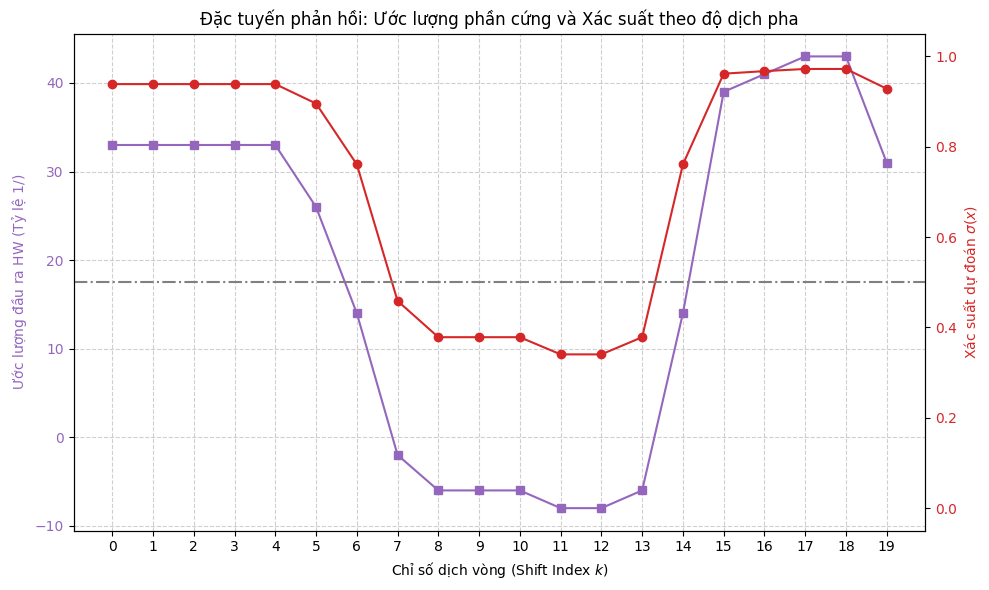

In [17]:
import numpy as np
import os
import matplotlib.pyplot as plt
from qonnx.core.modelwrapper import ModelWrapper
from finn.core.onnx_exec import execute_onnx

# =========================================================
# THÔNG SỐ KIỂM THỬ (TEST CONFIGURATION)
# =========================================================
NUM_POINTS = 20
OUTPUT_SCALE = 0.08270524442195892
GOLDEN_MODEL_PATH = "finn_ready_model.onnx"

if not os.path.exists(GOLDEN_MODEL_PATH):
    raise FileNotFoundError(f"Lỗi hệ thống: Không tìm thấy tệp mô hình tại {GOLDEN_MODEL_PATH}")

model_golden = ModelWrapper(GOLDEN_MODEL_PATH)
inp_name_gold = model_golden.graph.input[0].name
out_name_gold = model_golden.graph.output[0].name

t_base = np.linspace(0, 2 * np.pi, NUM_POINTS, endpoint=False)
base_sine_wave = np.sin(t_base)

shift_indices = []
logits = []
hw_equivalents = []
probabilities = []
predictions = []

print(f"{'Độ dịch (Mẫu)':<15} | {'Logit (Golden)':<15} | {'Ước lượng HW':<15} | {'Xác suất':<15} | {'Lớp phân loại'}")
print("-" * 80)

for shift in range(NUM_POINTS):
    # Dịch vòng tín hiệu để kiểm tra tính bất biến theo phép dịch
    shifted_sine = np.roll(base_sine_wave, -shift)
    
    inp_tensor = shifted_sine.astype(np.float32).reshape(1, 1, 1, NUM_POINTS)
    ret_golden = execute_onnx(model_golden, {inp_name_gold: inp_tensor})
    res_logit = ret_golden[out_name_gold].flatten()[0]
    
    estimated_hw_val = res_logit / OUTPUT_SCALE
    
    # Tính toán hàm kích hoạt Sigmoid
    prob = 1.0 / (1.0 + np.exp(-res_logit))
    pred_class = 1 if prob > 0.5 else 0
    
    # Lưu trữ dữ liệu cho mục đích trực quan hóa
    shift_indices.append(shift)
    logits.append(res_logit)
    hw_equivalents.append(estimated_hw_val)
    probabilities.append(prob)
    predictions.append(pred_class)
    
    print(f"{shift:<15} | {res_logit:<15.4f} | {estimated_hw_val:<15.4f} | {prob:<15.4f} | {pred_class}")

fig, ax1 = plt.subplots(figsize=(10, 6))

color_hw = 'tab:purple'
ax1.set_xlabel('Chỉ số dịch vòng (Shift Index $k$)')
ax1.set_ylabel(f'Ước lượng đầu ra HW (Tỷ lệ $1/\alpha$)', color=color_hw)
ax1.plot(shift_indices, hw_equivalents, marker='s', linestyle='-', color=color_hw, label='Dự kiến phần cứng (Float)')
ax1.tick_params(axis='y', labelcolor=color_hw)
ax1.set_xticks(shift_indices)
ax1.grid(True, linestyle='--', alpha=0.6)

ax2 = ax1.twinx()  
color_prob = 'tab:red'
ax2.set_ylabel('Xác suất dự đoán $\sigma(x)$', color=color_prob)
ax2.plot(shift_indices, probabilities, marker='o', linestyle='-', color=color_prob, label='Probability')
ax2.tick_params(axis='y', labelcolor=color_prob)
ax2.set_ylim(-0.05, 1.05)
ax2.axhline(y=0.5, color='gray', linestyle='-.', label='Ngưỡng quyết định (0.5)')

plt.title("Đặc tuyến phản hồi: Ước lượng phần cứng và Xác suất theo độ dịch pha")
fig.tight_layout()
plt.show()